<a href="https://colab.research.google.com/github/deshapriya123/financial-fraud-detection-system/blob/main/Financial_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this in your first cell to mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
# The dataset was downloaded to the current working directory
df = pd.read_csv('creditcard.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Exploratory Data Analysis & Imbalance Visualization

/tmp/ipykernel_7400/4148192647.py:10: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort=True)


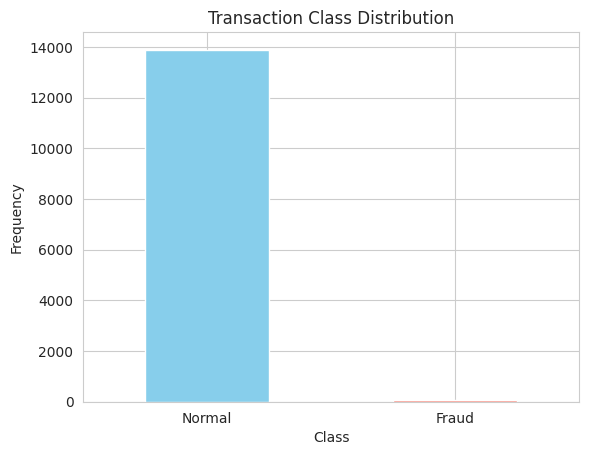

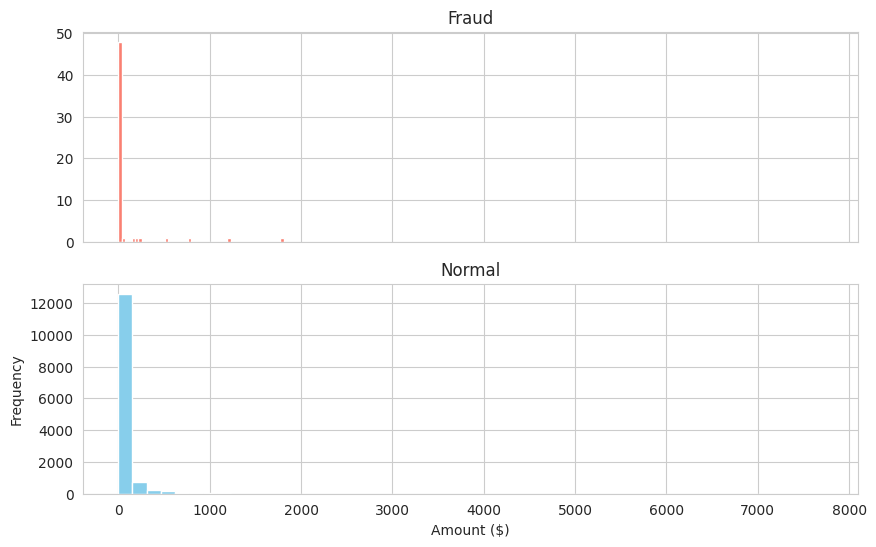

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style('whitegrid')

# 1. Visualize Class Imbalance
count_classes = pd.value_counts(df['Class'], sort=True)
count_classes.plot(kind='bar', rot=0, color=['skyblue', 'salmon'])
plt.title("Transaction Class Distribution")
plt.xticks(range(2), ['Normal', 'Fraud'])
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

# 2. Compare Amount distributions
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.hist(fraud.Amount, bins=50, color='salmon')
ax1.set_title('Fraud')
ax2.hist(normal.Amount, bins=50, color='skyblue')
ax2.set_title('Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.show()

Splitting and Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop rows with NaN values from the DataFrame
df.dropna(inplace=True)

# 1. Define Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Split into Train/Test (80/20 ratio)
# 'stratify=y' ensures the fraud ratio is maintained
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale the Data
# Use StandardScaler to give features a mean of 0 and std dev of 1
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

# 'Time' is often dropped or scaled similarly if you find it relevant
X_train['Time'] = scaler.fit_transform(X_train[['Time']])
X_test['Time'] = scaler.transform(X_test[['Time']])

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (11162, 30)
Testing set shape: (2791, 30)


In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
sm = SMOTE(random_state=42)

# Resample the training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}")
print(f"Class distribution after SMOTE: {y_train_res.value_counts()}")

Original training shape: (11162, 30)
Resampled training shape: (22234, 30)
Class distribution after SMOTE: Class
0.0    11117
1.0    11117
Name: count, dtype: int64


Model Training and Evaluation

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2780
         1.0       0.91      0.91      0.91        11

    accuracy                           1.00      2791
   macro avg       0.95      0.95      0.95      2791
weighted avg       1.00      1.00      1.00      2791



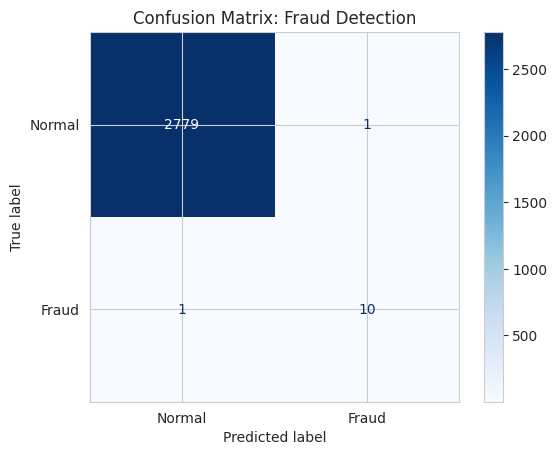

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

# 2. Predict on the test set
y_pred = rf_model.predict(X_test)

# 3. Display the results
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Fraud Detection')
plt.show()

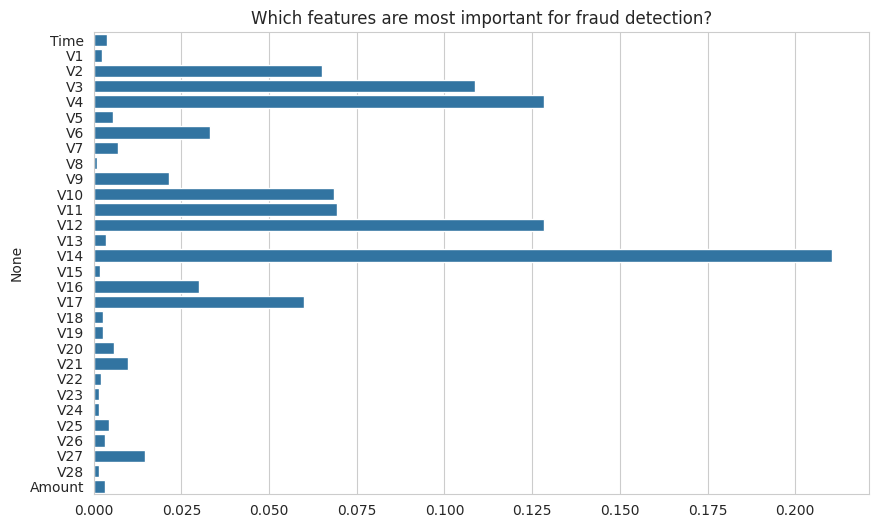

In [ ]:
# Visualize Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title('Which features are most important for fraud detection?')
plt.show()

In [ ]:
import joblib

# Save the trained model and the scaler (you need the scaler to transform new inputs!)
joblib.dump(rf_model, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
